# prepare mmidas input data here 
1. only snRNA 
2. only retroseq (include the batchcorrection)
3. concatenate snRNA and retro, after correcting for BN for retro

In [1]:
import scanpy as sc
import numpy as np
import anndata
import scvi
import matplotlib.pyplot as plt 
import pandas as pd

## 1. snRNA

/scratch/fast/11105015/ipykernel_1644988/705127160.py:3: FutureWarning: The behavior of Series.replace (and DataFrame.replace) with CategoricalDtype is deprecated. In a future version, replace will only be used for cases that preserve the categories. To change the categories, use ser.cat.rename_categories instead.
  adata_foo.obs['sex'] = adata_foo.obs['sex'].replace({'M;M;M;M;M;M;M;M;M;M': 'M', 'F;F;F;F;F;F;F;F;F;F': 'F'})


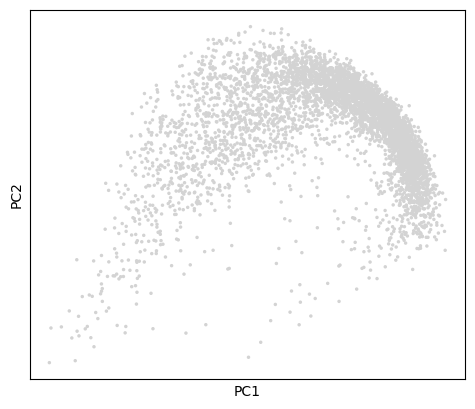

In [2]:
myfilename_scRNA = '/home/shuonan.chen/scratch_shuonan/LC_scRNAseq/processed_data/snRNAseq_LCNE_BN_d4_1-5k.h5ad'
adata_foo = sc.read_h5ad(myfilename_scRNA)
adata_foo.obs['sex'] = adata_foo.obs['sex'].replace({'M;M;M;M;M;M;M;M;M;M': 'M', 'F;F;F;F;F;F;F;F;F;F': 'F'})
adata_BN = anndata.AnnData(adata_foo.layers['BN'])
adata_BN.obs = adata_foo.obs.copy()
adata_BN.obsm = adata_foo.obsm.copy()
adata_BN.var = adata_foo.var.copy()
adata_sc = adata_BN.copy()

sc.tl.pca(adata_sc)
a=sc.pl.pca(adata_sc, show = False)
a.set_aspect('equal')

In [3]:
adata_sc.write_h5ad('/home/shuonan.chen/scratch_shuonan/code/LC-NE-MixRep/data/snRNA_BN_norm1.h5ad')